# Stationarity and autoregressive models

Most time series models assume that the process is **(weakly) stationary**: its mean and variance do not change over time, and the correlation between $X_t$ and $X_{t+h}$ depends only on the lag $h$, not on $t$. Under this assumption, the past carries information about the future that we can estimate and exploit.

The key tools are the **autocorrelation function** (ACF), $\rho(h) = \mathrm{Cor}(X_t, X_{t+h})$, and the **partial autocorrelation function** (PACF), the correlation between $X_t$ and $X_{t+h}$ after removing the effect of the values in between.

This notebook:

1. derives the ACF of a simple process by hand and checks it against simulations;
2. studies an **autoregressive** process: when it is stationary, what its realizations look like, and how its ACF and PACF identify it;
3. shows what goes wrong when a stationary model is fitted to a **non-stationary** series (global temperature), and how differencing fixes it;
4. uses an AR model to **forecast** a physical measurement and evaluates the forecast on held-out data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, adfuller
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.dpi"] = 100

## 1. A process built from coin tosses

Toss a fair coin repeatedly and set $D_k = +1$ for heads and $D_k = -1$ for tails. Define

$$X_k = a + D_k + b \, D_{k-1} .$$

Since the $D_k$ are independent with mean 0 and variance 1:

- $E[X_k] = a$ and $\mathrm{Var}(X_k) = 1 + b^2$, constant in time;
- $\mathrm{Cov}(X_k, X_{k+1}) = \mathrm{Cov}(D_k + bD_{k-1},\, D_{k+1} + bD_k) = b$, so $\rho(1) = \dfrac{b}{1 + b^2}$;
- for $h \ge 2$, $X_k$ and $X_{k+h}$ share no coin toss, so $\rho(h) = 0$.

The process is weakly stationary, and its memory lasts exactly one step. (It is a *moving average* process of order 1.) We simulate it with $a = 2$, $b = -0.7$, for which $\rho(1) = -0.7 / 1.49 \approx -0.47$.

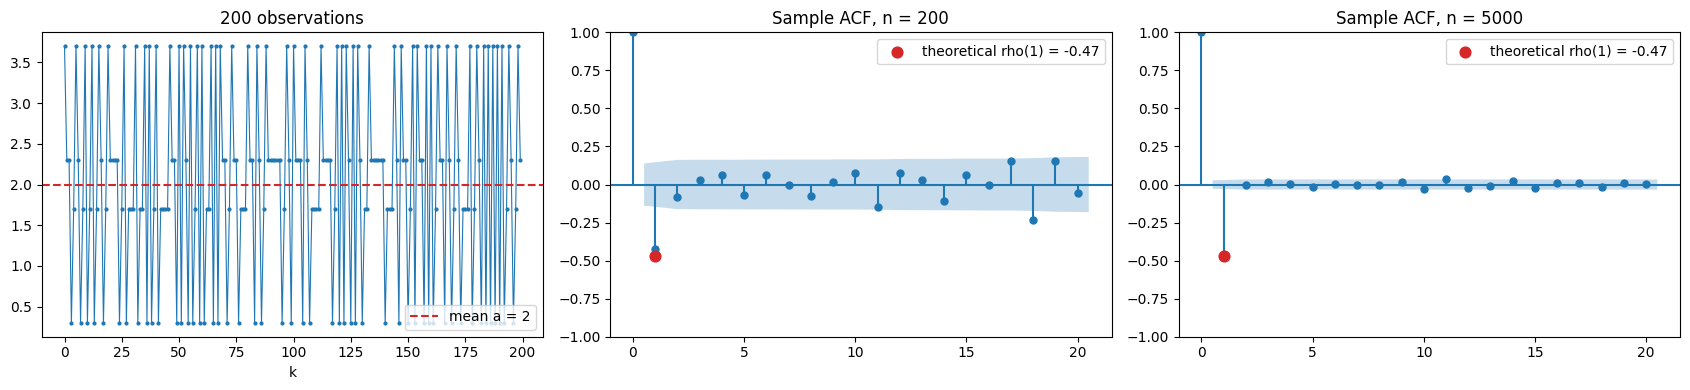

In [2]:
rng = np.random.default_rng(1)
a, b = 2, -0.7

def coin_process(n):
    d = rng.choice([-1, 1], size=n + 1)
    return a + d[1:] + b * d[:-1]

x = coin_process(200)
rho1 = b / (1 + b ** 2)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(x, lw=0.8, marker=".", ms=4)
axes[0].axhline(a, color="tab:red", ls="--", label=f"mean a = {a}")
axes[0].set(title="200 observations", xlabel="k")
axes[0].legend(loc="lower right")
for ax, n in zip(axes[1:], [200, 5000]):
    plot_acf(coin_process(n), lags=20, ax=ax, title=f"Sample ACF, n = {n}")
    ax.scatter([1], [rho1], color="tab:red", zorder=5, s=60, label=f"theoretical rho(1) = {rho1:.2f}")
    ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

The sample ACF matches the theory: a clear negative value at lag 1, close to −0.47, and nothing significant afterwards. With 200 observations a few lags poke slightly outside the 95% band, as expected by chance (about 1 in 20); with 5,000 observations the estimates are much more precise and the band much narrower.

The process can only take four values ($a \pm 1 \pm b$), and the negative $\rho(1)$ is visible in the series too: a high value tends to be followed by a lower one, giving the series its jagged look.

## 2. An autoregressive process

An autoregressive process of order $p$, AR($p$), regresses the series on its own past:

$$X_t = \phi_1 X_{t-1} + \dots + \phi_p X_{t-p} + W_t ,$$

where $W_t$ is white noise. We study

$$X_t = 1.21\,X_{t-1} - 0.5\,X_{t-2} - 0.13\,X_{t-3} + 0.24\,X_{t-4} + W_t, \qquad W_t \sim \mathcal{N}(0, 1).$$

### Is it stationary?

An AR process is stationary if and only if all roots of its characteristic polynomial

$$\Phi(z) = 1 - 1.21 z + 0.5 z^2 + 0.13 z^3 - 0.24 z^4$$

lie **outside the unit circle** ($|z| > 1$).

roots:           [-2.083+0.j     0.714-1.079j  0.714+1.079j  1.195+0.j   ]
absolute values: [2.083 1.294 1.294 1.195]
stationary:      True


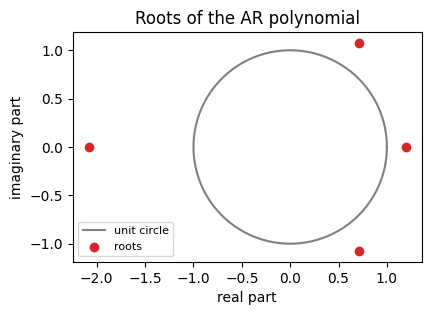

In [3]:
ar4 = ArmaProcess(ar=[1, -1.21, 0.5, 0.13, -0.24])
roots = ar4.arroots
print("roots:          ", np.round(roots, 3))
print("absolute values:", np.round(np.abs(roots), 3))
print("stationary:     ", ar4.isstationary)

theta = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(np.cos(theta), np.sin(theta), color="grey", label="unit circle")
ax.scatter(roots.real, roots.imag, color="tab:red", zorder=3, label="roots")
ax.set(aspect="equal", xlabel="real part", ylabel="imaginary part", title="Roots of the AR polynomial")
ax.legend(loc="lower left", fontsize=8)
plt.show()

All four roots have modulus larger than 1 (the smallest is 1.195), so the process is stationary. The pair of complex roots gives the process a **pseudo-periodic** behaviour: its ACF oscillates.

What would a non-stationary AR process look like? The simplest one is the **random walk**, $X_t = X_{t-1} + W_t$, whose polynomial $1 - z$ has its root exactly on the unit circle. We simulate both:

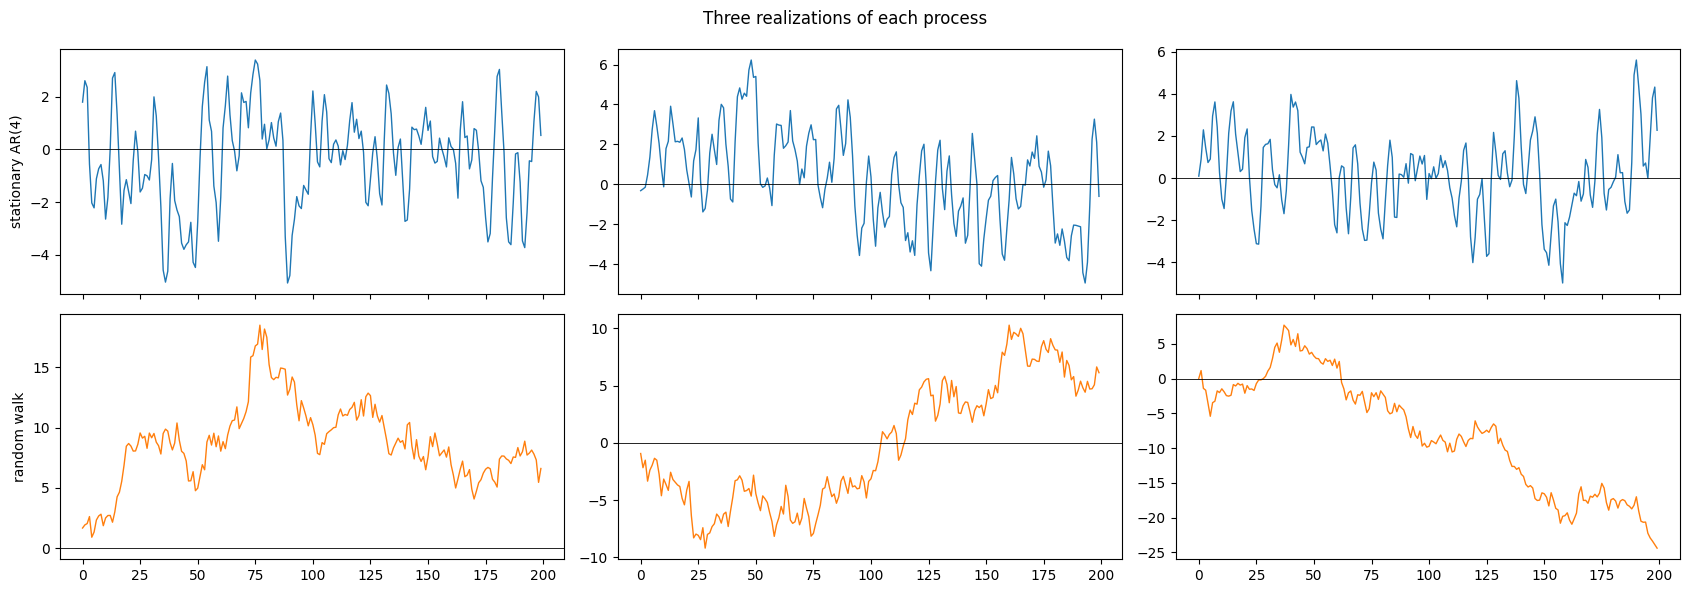

In [4]:
np.random.seed(3)
fig, axes = plt.subplots(2, 3, figsize=(17, 6), sharex=True)
for ax in axes[0]:
    ax.plot(ar4.generate_sample(nsample=200), lw=1)
    ax.axhline(0, color="black", lw=0.6)
axes[0, 0].set_ylabel("stationary AR(4)")
random_walk = ArmaProcess(ar=[1, -1])
for ax in axes[1]:
    ax.plot(random_walk.generate_sample(nsample=200), lw=1, color="tab:orange")
    ax.axhline(0, color="black", lw=0.6)
axes[1, 0].set_ylabel("random walk")
fig.suptitle("Three realizations of each process")
fig.tight_layout()
plt.show()

The three AR(4) paths are different point by point, but they share their character: they fluctuate around zero within the same range and with a similar typical distance between peaks, without being truly periodic. The random walks instead wander away with no level to return to, and each path looks like it has a different "trend". This is the hallmark of non-stationarity.

### Identifying the order: ACF and PACF

For an AR($p$) process, the ACF decays gradually (here as a damped oscillation), while the PACF **cuts off after lag $p$**: once the $p$ previous values are known, older values add no information.

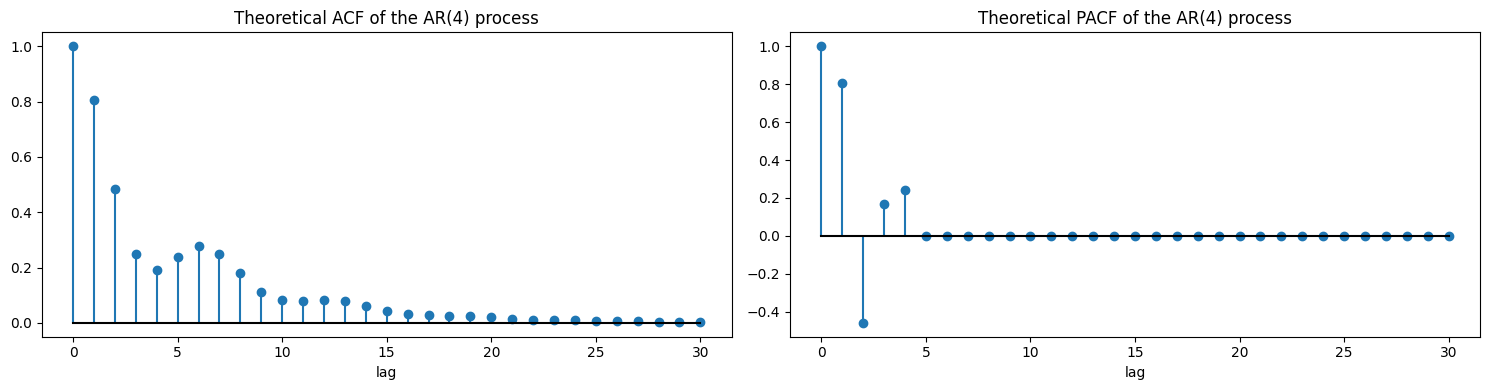

theoretical PACF, lags 1-6: [ 0.804 -0.458  0.17   0.24  -0.    -0.   ]


In [5]:
lags = 30
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, values, name in [(axes[0], ar4.acf(lags + 1), "ACF"), (axes[1], ar4.pacf(lags + 1), "PACF")]:
    ax.stem(range(lags + 1), values, basefmt="black")
    ax.set(title=f"Theoretical {name} of the AR(4) process", xlabel="lag")
fig.tight_layout()
plt.show()
print("theoretical PACF, lags 1-6:", np.round(ar4.pacf(7)[1:], 3))

The ACF is a slowly damped wave, and the PACF is non-zero exactly up to lag 4 and zero afterwards. The PACF at lag $p$ always equals the last coefficient $\phi_p$ (0.24 here). In practice we only see sample estimates, which are noisy, but this is the pattern we look for to choose $p$.

## 3. Non-stationary data: global temperature

Can the warming trend of the global temperature be explained as a stationary random fluctuation? We take the annual mean of the monthly anomalies (1850–2016) and look at its ACF.

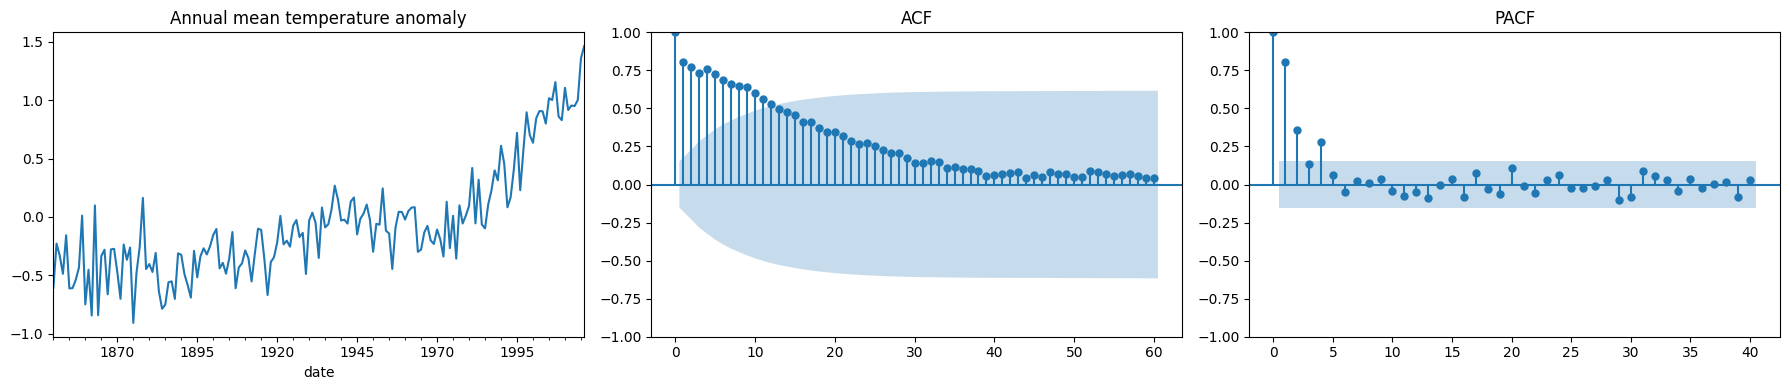

Augmented Dickey-Fuller test, p-value: 0.996


In [6]:
monthly = pd.read_csv("data/global_temperature_monthly.csv", parse_dates=["date"], index_col="date")["anomaly"]
annual = monthly[:"2016"].resample("YS").mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
annual.plot(ax=axes[0], title="Annual mean temperature anomaly")
plot_acf(annual, lags=60, ax=axes[1], title="ACF")
plot_pacf(annual, lags=40, ax=axes[2], title="PACF", method="ywm")
fig.tight_layout()
plt.show()
print(f"Augmented Dickey-Fuller test, p-value: {adfuller(annual)[1]:.3f}")

The ACF decays extremely slowly: the series is still correlated with itself 30 years apart. This is the typical signature of a **trend**, not of a stationary process. The augmented Dickey-Fuller test, whose null hypothesis is a unit root (random-walk-like behaviour), cannot reject non-stationarity (p ≈ 1).

What happens if we ignore this and fit a stationary AR(4) model anyway, then forecast the next 100 years?

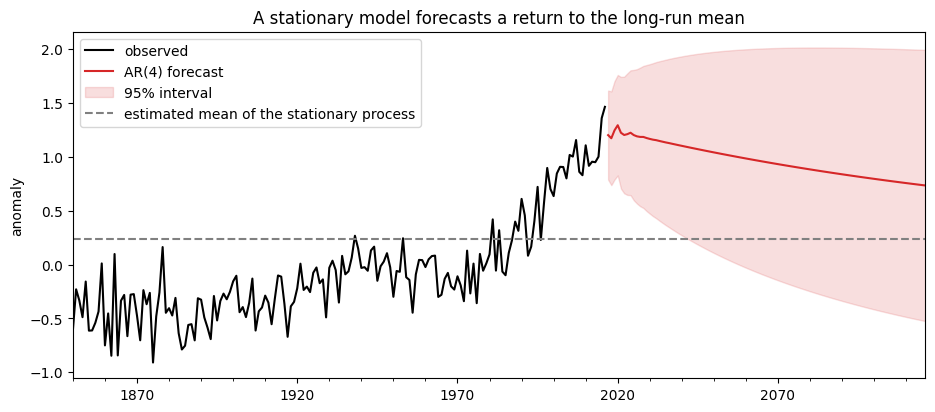

In [7]:
ar_levels = ARIMA(annual, order=(4, 0, 0)).fit()
forecast_ar = ar_levels.get_forecast(100).summary_frame()

fig, ax = plt.subplots(figsize=(11, 4.5))
annual.plot(ax=ax, color="black", label="observed")
forecast_ar["mean"].plot(ax=ax, color="tab:red", label="AR(4) forecast")
ax.fill_between(forecast_ar.index, forecast_ar["mean_ci_lower"], forecast_ar["mean_ci_upper"], color="tab:red", alpha=0.15, label="95% interval")
ax.axhline(ar_levels.params["const"], color="grey", ls="--", label="estimated mean of the stationary process")
ax.set(title="A stationary model forecasts a return to the long-run mean", ylabel="anomaly", xlabel="")
ax.legend(loc="upper left")
plt.show()

A stationary process always reverts to its mean, so the AR(4) forecast slowly drifts back down towards the average of the whole 167 years, as if the warming were a temporary excursion. This contradicts both the physics and the shape of the data. The model is not wrong because of its parameters; it is the wrong **kind** of model.

The standard remedy is to model the **differences** $\Delta X_t = X_t - X_{t-1}$, the year-to-year changes, which are stationary. An ARIMA($p$, 1, $q$) model does this; adding a constant drift to the differences allows for a systematic trend.

In [8]:
change = annual.diff().dropna()
print(f"ADF test on the yearly changes, p-value: {adfuller(change)[1]:.1e}")

candidates = {order: ARIMA(annual, order=order, trend="t").fit() for order in [(1, 1, 0), (2, 1, 0), (0, 1, 1), (1, 1, 1)]}
print(pd.Series({f"ARIMA{o} + drift": m.aic for o, m in candidates.items()}, name="AIC").round(1).sort_values())

best = candidates[(0, 1, 1)]
print()
print(best.summary().tables[1])

ADF test on the yearly changes, p-value: 3.6e-20
ARIMA(0, 1, 1) + drift   -37.8
ARIMA(1, 1, 1) + drift   -35.9
ARIMA(2, 1, 0) + drift   -11.2
ARIMA(1, 1, 0) + drift    -6.1
Name: AIC, dtype: float64

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0099      0.004      2.421      0.015       0.002       0.018
ma.L1         -0.7578      0.056    -13.484      0.000      -0.868      -0.648
sigma2         0.0447      0.005      9.090      0.000       0.035       0.054


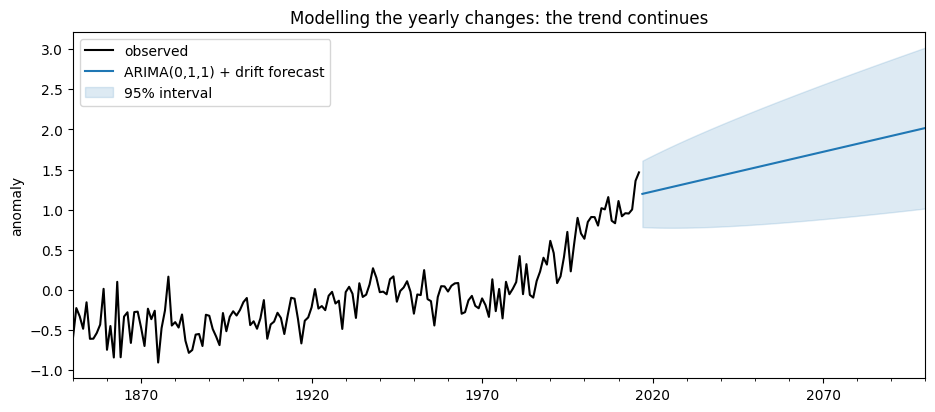

estimated drift: 0.0099 per year (about 1.0 degrees per century)


In [9]:
forecast_diff = best.get_forecast(84).summary_frame()

fig, ax = plt.subplots(figsize=(11, 4.5))
annual.plot(ax=ax, color="black", label="observed")
forecast_diff["mean"].plot(ax=ax, color="tab:blue", label="ARIMA(0,1,1) + drift forecast")
ax.fill_between(forecast_diff.index, forecast_diff["mean_ci_lower"], forecast_diff["mean_ci_upper"], color="tab:blue", alpha=0.15, label="95% interval")
ax.set(title="Modelling the yearly changes: the trend continues", ylabel="anomaly", xlabel="")
ax.legend(loc="upper left")
plt.show()
print(f"estimated drift: {best.params['x1']:.4f} per year (about {100 * best.params['x1']:.1f} degrees per century)")

The yearly changes are clearly stationary, and the best model by AIC is an ARIMA(0,1,1) with drift: the series moves by a constant average step each year plus noise, partly corrected in the following year. The drift is about **0.01 degrees per year**, averaged over the whole period since 1850. Since the trend has been much steeper since the 1970s, this extrapolation is, if anything, conservative.

The prediction interval widens quickly, because the model allows the random part of the trend to accumulate. Statistical extrapolation over decades is no substitute for a physical climate model, but the comparison makes the key point: whether the series is treated as stationary or not completely changes the conclusions.

## 4. Forecasting with an AR model: force on a cylinder

The last dataset contains 320 measurements of the vertical force on a cylinder in a water tank, taken every 0.15 seconds. We fit an AR model on the first 280 observations and forecast the last 40, which the model never sees.

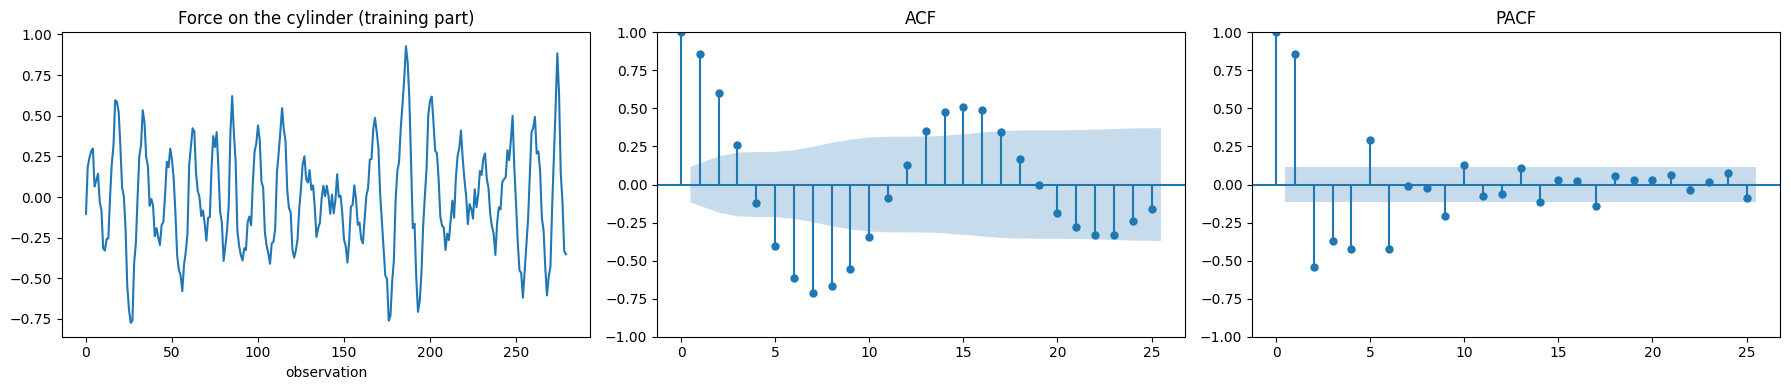

In [10]:
force = pd.read_csv("data/cylinder_force.csv")["force"]
train, test = force[:280], force[280:]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
train.plot(ax=axes[0], title="Force on the cylinder (training part)", xlabel="observation")
plot_acf(train, lags=25, ax=axes[1], title="ACF")
plot_pacf(train, lags=25, ax=axes[2], title="PACF", method="ywm")
fig.tight_layout()
plt.show()

The series oscillates regularly. The ACF is a damped oscillation, and the PACF has large values up to lag 6 and is essentially zero afterwards. This is the pattern of an AR(6) process. We fit it, together with a simpler AR(2) for comparison, and check that the residuals no longer contain any dependence.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0076      0.014     -0.564      0.573      -0.034       0.019
ar.L1          1.2051      0.051     23.567      0.000       1.105       1.305
ar.L2         -0.3866      0.078     -4.974      0.000      -0.539      -0.234
ar.L3          0.1662      0.070      2.383      0.017       0.030       0.303
ar.L4         -0.7461      0.075     -9.929      0.000      -0.893      -0.599
ar.L5          0.7717      0.077      9.999      0.000       0.620       0.923
ar.L6         -0.4475      0.061     -7.344      0.000      -0.567      -0.328
sigma2         0.0091      0.001     12.375      0.000       0.008       0.011


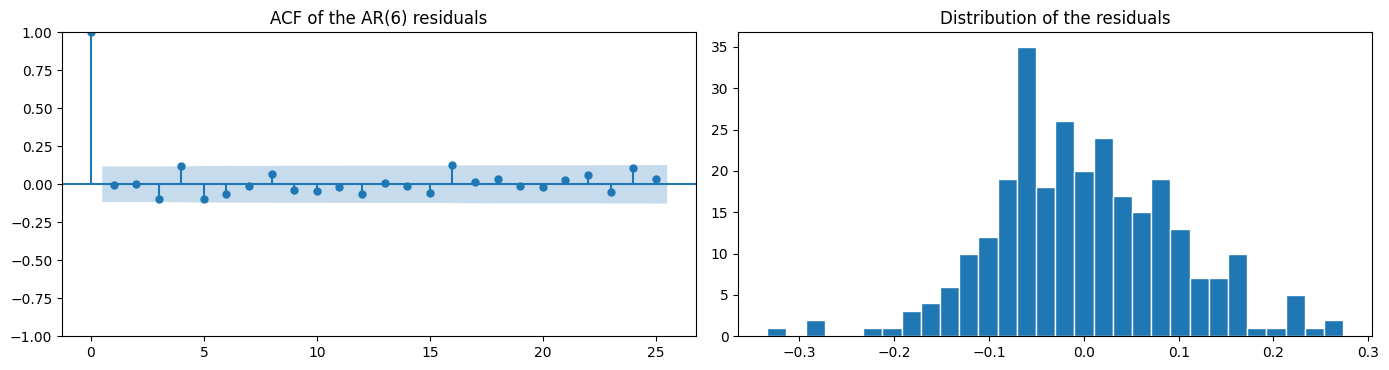

In [11]:
ar6 = ARIMA(train, order=(6, 0, 0)).fit()
print(ar6.summary().tables[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
plot_acf(ar6.resid, lags=25, ax=axes[0], title="ACF of the AR(6) residuals")
axes[1].hist(ar6.resid, bins=30, edgecolor="white")
axes[1].set_title("Distribution of the residuals")
fig.tight_layout()
plt.show()

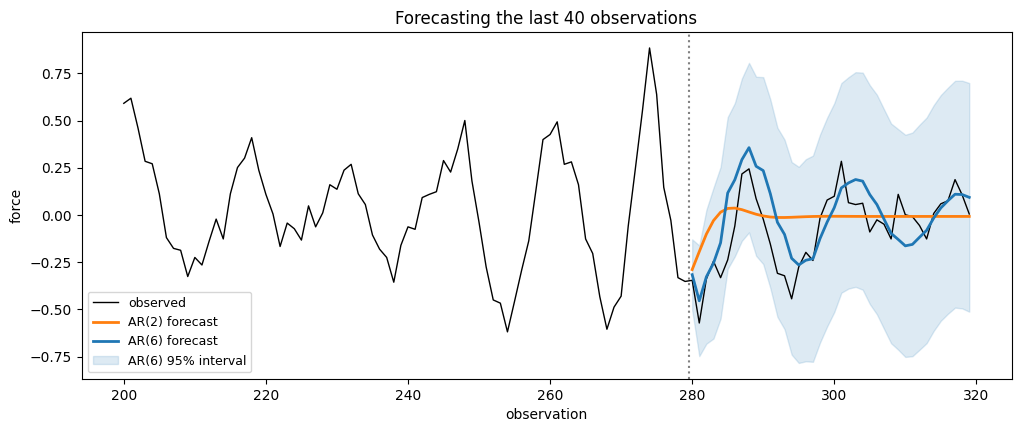

AR(2)                       0.182
AR(6)                       0.146
training mean (no model)    0.206
Name: RMSE on the 40 held-out points, dtype: float64

In [12]:
results = {}
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(force.index[200:], force[200:], color="black", lw=1, label="observed")
for p, color in [(2, "tab:orange"), (6, "tab:blue")]:
    model = ar6 if p == 6 else ARIMA(train, order=(p, 0, 0)).fit()
    fc = model.get_forecast(len(test)).summary_frame()
    fc.index = test.index
    ax.plot(fc.index, fc["mean"], color=color, lw=2, label=f"AR({p}) forecast")
    if p == 6:
        ax.fill_between(fc.index, fc["mean_ci_lower"], fc["mean_ci_upper"], color=color, alpha=0.15, label="AR(6) 95% interval")
    results[f"AR({p})"] = np.sqrt(np.mean((test - fc["mean"]) ** 2))
results["training mean (no model)"] = np.sqrt(np.mean((test - train.mean()) ** 2))
ax.axvline(279.5, color="grey", ls=":")
ax.set(title="Forecasting the last 40 observations", xlabel="observation", ylabel="force")
ax.legend(loc="lower left", fontsize=9)
plt.show()
pd.Series(results, name="RMSE on the 40 held-out points").round(3)

The AR(6) residuals show no remaining autocorrelation, so the model has captured the dependence structure. Its forecast follows the oscillation of the held-out data for several cycles before slowly fading towards the mean, as every stationary forecast eventually does. The AR(2) cannot represent this oscillation and its forecast flattens to the mean after a few steps. Both models beat the no-model baseline of predicting the mean. The observed values stay within the 95% prediction interval.

## Summary

- **Weak stationarity** means constant mean, constant variance and correlations that depend only on the lag. The ACF can be derived by hand for simple processes, and the sample ACF converges to it as $n$ grows.
- An AR process is stationary when the roots of its polynomial lie **outside the unit circle**. Complex roots produce pseudo-periodic behaviour; a root on the unit circle (random walk) produces wandering, trend-like paths.
- For AR($p$) the **PACF cuts off after lag $p$**, which is how the order is identified.
- A slowly decaying ACF signals **non-stationarity**. A stationary model then forecasts a return to the mean, which can be badly wrong. **Differencing** (ARIMA) is the standard remedy.
- Forecasts should always be evaluated on **held-out data** and compared with a simple baseline.